<a href="https://colab.research.google.com/github/poonamkhot123/Machine-Learning-Practice-Hub/blob/main/Day_25_Normalization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/Wine dataset.csv",header=None,usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class label  179 non-null    object
 1   Alcohol      179 non-null    object
 2   Malic acid   179 non-null    object
dtypes: object(3)
memory usage: 4.3+ KB


/tmp/ipykernel_14375/4152103811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Alcohol'] = pd.to_numeric(df['Alcohol'])


<Axes: xlabel='Alcohol', ylabel='Density'>

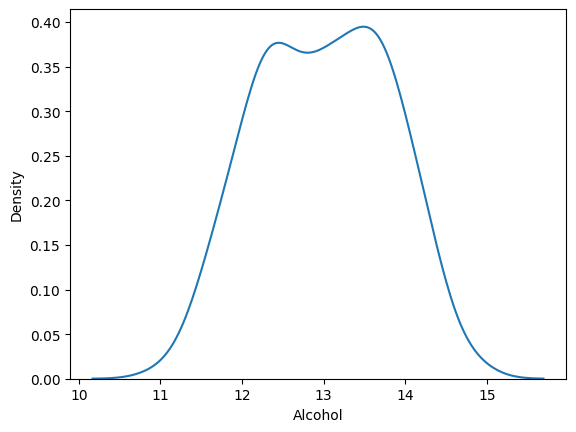

In [18]:
df = df.iloc[1:]
df['Alcohol'] = pd.to_numeric(df['Alcohol'])
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

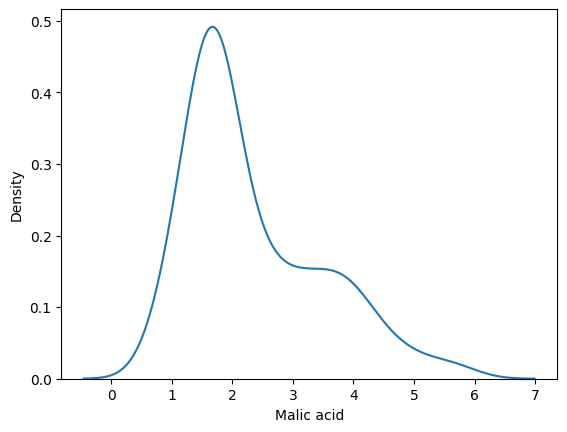

In [19]:
df.loc[:, 'Malic acid'] = pd.to_numeric(df['Malic acid'])
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

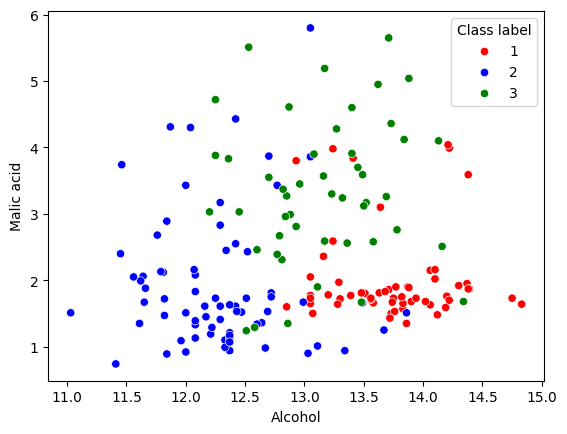

In [22]:
color_dict={1:'red',3:'green',2:'blue'}
df.loc[:, 'Class label'] = pd.to_numeric(df['Class label'])
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

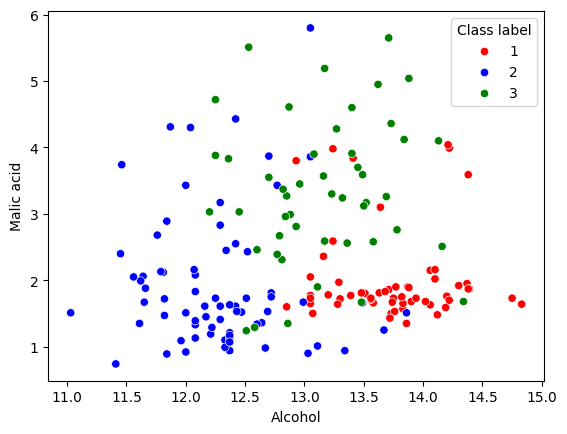

In [23]:
color_dict={1:'red',3:'green',2:'blue'}
df.loc[:, 'Class label'] = pd.to_numeric(df['Class label'])
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Class label',axis=1),df["Class label"],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((123, 2), (54, 2))

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [29]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,123.0,123.0
mean,13.0,2.3
std,0.8,1.2
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.8
75%,13.6,3.1
max,14.8,5.8


In [30]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,123.0,123.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


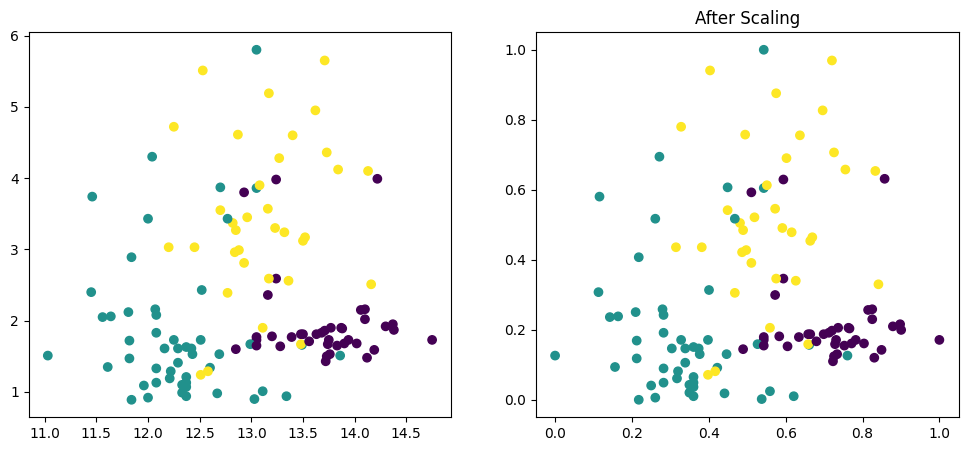

In [31]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train["Alcohol"],X_train['Malic acid'],c=y_train)
ax2.scatter(X_train_scaled["Alcohol"],X_train_scaled["Malic acid"],c=y_train)
ax2.set_title("After Scaling")
plt.show()

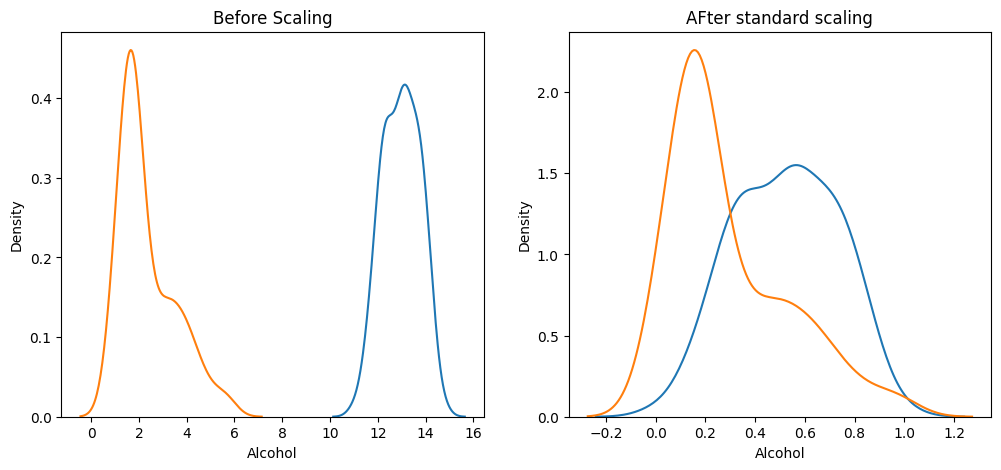

In [32]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'],ax=ax1)
sns.kdeplot(X_train['Malic acid'],ax=ax1)

#after scaling
ax2.set_title("AFter standard scaling")
sns.kdeplot(X_train_scaled["Alcohol"],ax=ax2)
sns.kdeplot(X_train_scaled["Malic acid"],ax=ax2)
plt.show()

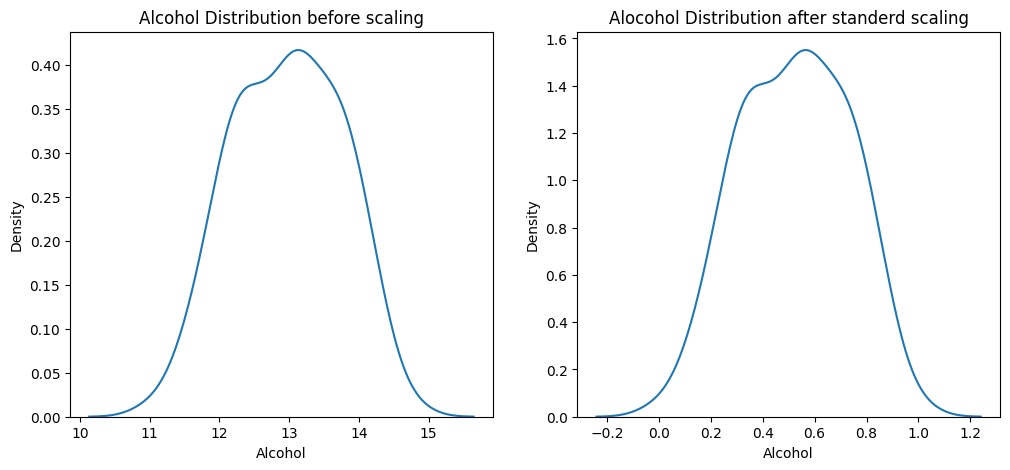

In [34]:
fig ,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Alcohol Distribution before scaling")
sns.kdeplot(X_train["Alcohol"],ax=ax1)

# after scaling
ax2.set_title("Alocohol Distribution after standerd scaling")
sns.kdeplot(X_train_scaled['Alcohol'],ax=ax2)
plt.show()
